# Model 1 — Forecaster (LSTM / GRU / Transformer)

In [ ]:
import os, time, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


> **LLM note:** The following cell was generated with Claude assistance (Level 3 skeleton).
> Cleaned up and restructed by Claude and Github Copilot.

In [ ]:
# Data source
DATA_MODE       = 'bsm2'                       # 'bsm2' | 'real'
DATA_PATH_BSM2  = 'DATA/BSM2_extracted_data.csv'
DATA_PATH_REAL  = ''
LABELS_PATH     = '' 
TIMESTAMP_COL   = 'timestamp'
TIMESTAMP_FMT   = '%Y-%m-%d %H:%M:%S'
RESOLUTION_MIN  = 15                           # 15 for BSM2, 10 for real
N_ROWS          = None                         # None = use all rows

# Variables (target + features shared with VAE) 
TARGET_VARS  = ['S_PO4_e']
FEATURE_VARS = [
    'Q_in', 'Temp_in', 'S_PO4_in', 'S_NH4_in', 'S_F_in', 'S_A_in',
    'X_S_in', 'X_TSS_in',
    'S_PO4_r1', 'X_PAO_r1', 'X_PP_r1', 'S_A_r1',
    'S_O2_r5', 'S_PO4_r5', 'S_NH4_r5',
    'S_O2_r7', 'S_PO4_r7', 'X_TSS_r7',
]

# Combined list
ALL_VARS    = TARGET_VARS + [v for v in FEATURE_VARS if v not in TARGET_VARS]
N_VARS      = len(ALL_VARS)
N_TARGETS   = len(TARGET_VARS)
TARGET_IDX  = list(range(N_TARGETS))

# Window length (shared with VAE)
INPUT_HOURS    = 12
HORIZON_HOURS  = 6                             
INPUT_STEPS    = int(INPUT_HOURS   * 60 / RESOLUTION_MIN)
HORIZON_STEPS  = int(HORIZON_HOURS * 60 / RESOLUTION_MIN)
STRIDE         = INPUT_STEPS // 4

# Splits
TRAIN_RATIO = 0.75; VAL_RATIO = 0.10           # test = for integration

# Data path
DATA_PATH = DATA_PATH_BSM2 if DATA_MODE == 'bsm2' else DATA_PATH_REAL


# Model-specific config
MODELS_TO_RUN = ['LSTM','GRU','Transformer']

BATCH_SIZE    = 64
EPOCHS        = 300
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
PATIENCE      = 25

HIDDEN_SIZE = 96
NUM_LAYERS  = 1
DROPOUT     = 0.15
NUM_HEADS   = 4

# Parameter overrides from optuna 
BEST_HPARAMS = {
    'LSTM': {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.07995021698161972, 'lr': 0.00420459820345132},
    'GRU': {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1961043371904594, 'lr': 0.003381561969783691},
    'Transformer': {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.05311886935714971, 'lr': 0.004460049154806768, 'num_heads': 4},
}

print(f'Mode: {DATA_MODE}   targets={TARGET_VARS}   n_features={N_VARS}')
print(f'Input={INPUT_STEPS} steps ({INPUT_HOURS} h), '
      f'horizon={HORIZON_STEPS} steps ({HORIZON_HOURS} h)')
print(f'Models to run: {MODELS_TO_RUN}')

Mode: bsm2   targets=['S_PO4_e']   n_features=19
Input=48 steps (12 h), horizon=24 steps (6 h)
Models to run: ['LSTM', 'GRU', 'Transformer']


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# DATA LOADING + SCALING + WINDOWING

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df[TIMESTAMP_COL], format=TIMESTAMP_FMT)
df = df.sort_values('timestamp').set_index('timestamp')
if N_ROWS: df = df.iloc[:N_ROWS].copy()
df_model = df[ALL_VARS].copy()
for col in ALL_VARS:
    df_model[col] = (df_model[col]
                     .interpolate('linear', limit_direction='both')
                     .ffill().bfill())

n = len(df_model)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

scaler = MinMaxScaler()
scaler.fit(df_model.values[:train_end])
data_scaled = scaler.transform(df_model.values)

print(f'Data: {n} rows | train={train_end}, val={val_end-train_end}, '
      f'test={n-val_end}')
print(f'Scaler: MinMaxScaler   |   scaled range '
      f'[{data_scaled[:train_end].min():.2f}, {data_scaled[:train_end].max():.2f}]')

def make_pairs(data, in_len, out_len, stride):
    X, Y = [], []
    for i in range(0, len(data) - in_len - out_len + 1, stride):
        X.append(data[i:i+in_len])
        Y.append(data[i+in_len:i+in_len+out_len, TARGET_IDX])
    return np.array(X), np.array(Y)

X_tr, Y_tr = make_pairs(data_scaled[:train_end],        INPUT_STEPS, HORIZON_STEPS, STRIDE)
X_va, Y_va = make_pairs(data_scaled[train_end:val_end], INPUT_STEPS, HORIZON_STEPS, STRIDE)
X_te, Y_te = make_pairs(data_scaled[val_end:],          INPUT_STEPS, HORIZON_STEPS, HORIZON_STEPS)
print(f'X_tr {X_tr.shape}  X_va {X_va.shape}  X_te {X_te.shape}')

class ForecastDS(Dataset):
    def __init__(s, X, Y): s.X, s.Y = torch.FloatTensor(X), torch.FloatTensor(Y)
    def __len__(s): return len(s.X)
    def __getitem__(s, i): return s.X[i], s.Y[i]

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(ForecastDS(X_tr, Y_tr), BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(ForecastDS(X_va, Y_va), BATCH_SIZE)
test_loader  = DataLoader(ForecastDS(X_te, Y_te), BATCH_SIZE)

Data: 34944 rows | train=26208, val=3494, test=5242
Scaler: MinMaxScaler   |   scaled range [0.00, 1.00]
X_tr (2179, 48, 19)  X_va (286, 48, 19)  X_te (216, 48, 19)


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# MODELS

class _RNNForecaster(nn.Module):
    def __init__(self, rnn_cls, n_in, h, nl, horizon, n_tgt, dropout=0.0):
        super().__init__()
        self.horizon, self.n_tgt = horizon, n_tgt
        self.enc = rnn_cls(n_in, h, nl, batch_first=True, bidirectional=True,
                           dropout=dropout if nl > 1 else 0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(h * 2, horizon * n_tgt)
    def forward(self, x):
        out, _ = self.enc(x)
        ctx = self.drop(out[:, -1, :])
        return self.head(ctx).view(-1, self.horizon, self.n_tgt)

class LSTMForecaster(_RNNForecaster):
    def __init__(self, *a, **kw): super().__init__(nn.LSTM, *a, **kw)
class GRUForecaster(_RNNForecaster):
    def __init__(self, *a, **kw): super().__init__(nn.GRU,  *a, **kw)

class TransformerForecaster(nn.Module):
    def __init__(self, n_in, h, nl, nh, horizon, n_tgt, dropout=0.0, max_len=2048):
        super().__init__()
        self.horizon, self.n_tgt = horizon, n_tgt
        self.input_proj = nn.Linear(n_in, h)
        self.pos_emb    = nn.Parameter(torch.randn(1, max_len, h) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=h, nhead=nh, dim_feedforward=h*4,
                                            dropout=dropout, batch_first=True,
                                            activation='gelu')
        self.enc = nn.TransformerEncoder(layer, num_layers=nl)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(h, horizon * n_tgt)
    def forward(self, x):
        h = self.input_proj(x) + self.pos_emb[:, :x.size(1)]
        h = self.enc(h)
        ctx = self.drop(h.mean(dim=1))
        return self.head(ctx).view(-1, self.horizon, self.n_tgt)

def build_model(name, hp=None):
    if hp is None: hp = BEST_HPARAMS.get(name, {})
    h  = hp.get('hidden_size', HIDDEN_SIZE)
    nl = hp.get('num_layers',  NUM_LAYERS)
    dr = hp.get('dropout',     DROPOUT)
    nh = hp.get('num_heads',   NUM_HEADS)
    if name == 'LSTM':        return LSTMForecaster(N_VARS, h, nl, HORIZON_STEPS, N_TARGETS, dr)
    if name == 'GRU':         return GRUForecaster (N_VARS, h, nl, HORIZON_STEPS, N_TARGETS, dr)
    if name == 'Transformer': return TransformerForecaster(N_VARS, h, nl, nh, HORIZON_STEPS, N_TARGETS, dr)
    raise ValueError(name)

for name in MODELS_TO_RUN:
    m = build_model(name).to(DEVICE)
    n_p = sum(p.numel() for p in m.parameters())
    print(f'  {name:<12s} params={n_p:>8,d}')

  LSTM         params= 158,744
  GRU          params= 417,048
  Transformer  params= 105,080


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# TRAINING LOOP

def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            loss = F.mse_loss(pred, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item() * x.size(0); n += x.size(0)
    return total / n

def train_model(name, verbose=True):
    torch.manual_seed(SEED)
    hp = BEST_HPARAMS.get(name, {})
    lr = hp.get('lr', LEARNING_RATE)
    model = build_model(name, hp).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=4)

    hist = {'train': [], 'val': [], 'lr': []}
    best_val, best_ep, best_state, pat = float('inf'), 0, None, 0
    t0 = time.time()
    for ep in range(EPOCHS):
        tl = run_epoch(model, train_loader, opt)
        vl = run_epoch(model, val_loader)
        sch.step(vl)
        hist['train'].append(tl); hist['val'].append(vl)
        hist['lr'].append(opt.param_groups[0]['lr'])
        if vl < best_val:
            best_val, best_ep = vl, ep + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat = 0
        else: pat += 1
        if verbose and ((ep+1) % 10 == 0 or ep < 3):
            print(f'  [{name}] ep {ep+1:3d}  train={tl:.5f}  val={vl:.5f}  pat={pat}/{PATIENCE}')
        if pat >= PATIENCE:
            if verbose: print(f'  [{name}] early stop @ ep {ep+1}')
            break
    model.load_state_dict(best_state); model = model.to(DEVICE)
    meta = {'name': name, 'best_val': best_val, 'best_epoch': best_ep,
            'train_time_s': time.time() - t0,
            'n_params': sum(p.numel() for p in model.parameters())}
    return model, hist, meta

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# OPTUNA (dont run after copying best params)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

MODELS_TO_TUNE = []
N_TRIALS       = 50
EPOCHS_TRIAL   = 300
PATIENCE_TRIAL = 25

def _suggest_hp(trial, name):
    h  = trial.suggest_categorical('hidden_size', [32, 64, 96, 128])
    nl = trial.suggest_int        ('num_layers', 1, 3)
    dr = trial.suggest_float      ('dropout', 0.05, 0.4)
    lr = trial.suggest_float      ('lr', 1e-4, 5e-3, log=True)
    hp = {'hidden_size': h, 'num_layers': nl, 'dropout': dr, 'lr': lr}
    if name == 'Transformer':
        nh = trial.suggest_categorical('num_heads', [2, 4, 8])
        if h % nh != 0: raise optuna.TrialPruned()
        hp['num_heads'] = nh
    return hp

def _trial_train(name, hp):
    torch.manual_seed(SEED)
    m   = build_model(name, hp).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=hp['lr'], weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=3)
    best, pat = float('inf'), 0
    for ep in range(EPOCHS_TRIAL):
        run_epoch(m, train_loader, opt)
        vl = run_epoch(m, val_loader)
        sch.step(vl)
        if vl < best: best, pat = vl, 0
        else:         pat += 1
        if pat >= PATIENCE_TRIAL: break
    return best

best_per_model = {}
for name in MODELS_TO_TUNE:
    study = optuna.create_study(
        study_name=f'forecast_{name}_{DATA_MODE}',
        storage=f'sqlite:///optuna_forecast_{name}_{DATA_MODE}.db',
        direction='minimize', load_if_exists=True,
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
    print(f'── Tuning {name} (existing trials: {len(study.trials)}) ──')
    study.optimize(lambda t: _trial_train(name, _suggest_hp(t, name)),
                   n_trials=N_TRIALS, show_progress_bar=True)
    print(f'  best val MSE: {study.best_value:.6f}')
    print(f'  best params:  {study.best_params}')
    best_per_model[name] = study.best_params

print('\n' + '═' * 60)
print('PASTE THIS INTO THE CONFIG CELL:')
print('═' * 60)
print('BEST_HPARAMS = {')
for n, hp in best_per_model.items():
    print(f"    '{n}': {{{', '.join(f"'{k}': {v!r}" for k, v in hp.items())}}},")
print('}')

best = {}
for name in ['LSTM', 'GRU', 'Transformer']:
    try:
        s = optuna.load_study(
            study_name=f'forecast_{name}_{DATA_MODE}',
            storage=f'sqlite:///optuna_forecast_{name}_{DATA_MODE}.db')
        best[name] = s.best_params
    except KeyError:
        pass

print('BEST_HPARAMS = {')
for n, hp in best.items():
    items = ', '.join(f"'{k}': {v!r}" for k, v in hp.items())
    print(f"    '{n}': {{{items}}},")
print('}')


════════════════════════════════════════════════════════════
PASTE THIS INTO THE CONFIG CELL:
════════════════════════════════════════════════════════════
BEST_HPARAMS = {
}
BEST_HPARAMS = {
    'LSTM': {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.07995021698161972, 'lr': 0.00420459820345132},
    'GRU': {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1961043371904594, 'lr': 0.003381561969783691},
    'Transformer': {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.05311886935714971, 'lr': 0.004460049154806768, 'num_heads': 4},
}


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# TRAINING

def inv_scale_target(arr_scaled, target_col=0):
    pad = np.zeros((len(arr_scaled), N_VARS))
    pad[:, target_col] = arr_scaled
    return scaler.inverse_transform(pad)[:, target_col]

def persistence_baseline(X, horizon):
    last = X[:, -1, TARGET_IDX]
    return np.broadcast_to(last[:, None, :], (len(X), horizon, N_TARGETS)).copy()

@torch.no_grad()
def predict(model, loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        P.append(model(x.to(DEVICE)).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(P), np.concatenate(Y)

results = {}
for name in MODELS_TO_RUN:
    print(f'\n── Training {name} ──')
    model, hist, meta = train_model(name)
    P, Y = predict(model, test_loader)
    Bsl  = persistence_baseline(X_te, HORIZON_STEPS)


    yt = inv_scale_target(Y[:, :, 0].ravel(), 0)
    yp = inv_scale_target(P[:, :, 0].ravel(), 0)
    yb = inv_scale_target(Bsl[:, :, 0].ravel(), 0)
    test_rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    test_mae  = float(mean_absolute_error(yt, yp))
    test_r2   = float(r2_score(yt, yp))
    bl_rmse   = float(np.sqrt(mean_squared_error(yt, yb)))

    results[name] = dict(model=model, hist=hist, meta=meta,
                         test_rmse=test_rmse, test_mae=test_mae, test_r2=test_r2,
                         baseline_rmse=bl_rmse)
    print(f'  test RMSE={test_rmse:.4f}  MAE={test_mae:.4f}  R²={test_r2:.4f}  '
          f'(persistence RMSE={bl_rmse:.4f})')


print('\n' + '═' * 72)
print(f'{"Model":<14s}{"RMSE":>10s}{"MAE":>10s}{"R²":>10s}{"vs persist.%":>14s}')
print('─' * 72)
for n, r in results.items():
    impr = (1 - r['test_rmse']/r['baseline_rmse']) * 100
    print(f'{n:<14s}{r["test_rmse"]:>10.4f}{r["test_mae"]:>10.4f}'
          f'{r["test_r2"]:>10.4f}{impr:>13.1f}%')


── Training LSTM ──
  [LSTM] ep   1  train=0.01924  val=0.00209  pat=0/25
  [LSTM] ep   2  train=0.00223  val=0.00172  pat=0/25
  [LSTM] ep   3  train=0.00177  val=0.00158  pat=0/25
  [LSTM] ep  10  train=0.00093  val=0.00093  pat=1/25
  [LSTM] ep  20  train=0.00066  val=0.00070  pat=3/25
  [LSTM] ep  30  train=0.00063  val=0.00050  pat=3/25
  [LSTM] ep  40  train=0.00054  val=0.00043  pat=2/25
  [LSTM] ep  50  train=0.00048  val=0.00040  pat=7/25
  [LSTM] ep  60  train=0.00045  val=0.00034  pat=0/25
  [LSTM] ep  70  train=0.00042  val=0.00034  pat=3/25
  [LSTM] ep  80  train=0.00041  val=0.00033  pat=3/25
  [LSTM] ep  90  train=0.00041  val=0.00033  pat=4/25
  [LSTM] ep 100  train=0.00039  val=0.00033  pat=14/25
  [LSTM] ep 110  train=0.00040  val=0.00033  pat=24/25
  [LSTM] early stop @ ep 111
  test RMSE=0.2532  MAE=0.1575  R²=0.9870  (persistence RMSE=1.3168)

── Training GRU ──
  [GRU] ep   1  train=0.01894  val=0.00193  pat=0/25
  [GRU] ep   2  train=0.00246  val=0.00329  pat=1/

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

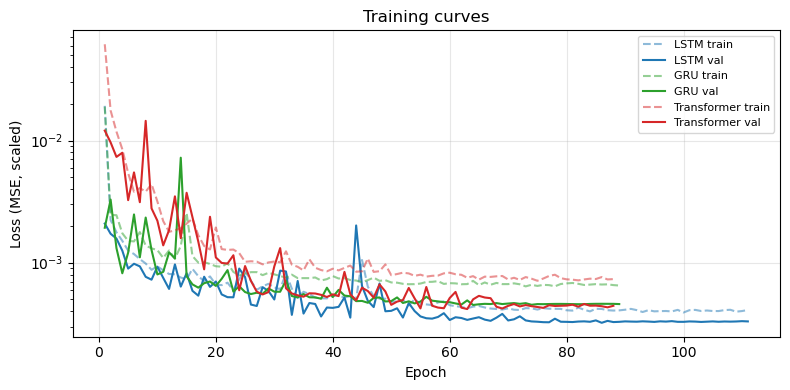

In [ ]:
#TRANING CURVE PLOT

colors = {'LSTM': '#1f77b4', 'GRU': '#2ca02c', 'Transformer': '#d62728'}
fig, ax = plt.subplots(figsize=(8, 4))
for name, r in results.items():
    h = r['hist']; ep = range(1, len(h['train']) + 1)
    ax.plot(ep, h['train'], '--', c=colors.get(name, 'k'), alpha=.5, label=f'{name} train')
    ax.plot(ep, h['val'],         c=colors.get(name, 'k'),               label=f'{name} val')
ax.set(xlabel='Epoch', ylabel='Loss (MSE, scaled)', yscale='log',
       title='Training curves')
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# SAVE CHECKPOINTS

os.makedirs('CHECKPOINTS', exist_ok=True)
for name, r in results.items():
    hp = BEST_HPARAMS.get(name, {})
    ckpt = {
        'state_dict': r['model'].state_dict(),
        'config': {
            'name': name,
            'INPUT_STEPS': INPUT_STEPS, 'HORIZON_STEPS': HORIZON_STEPS,
            'N_VARS': N_VARS, 'N_TARGETS': N_TARGETS,
            'TARGET_VARS': TARGET_VARS, 'FEATURE_VARS': FEATURE_VARS,
            'ALL_VARS': ALL_VARS,
            'HIDDEN_SIZE': hp.get('hidden_size', HIDDEN_SIZE),
            'NUM_LAYERS':  hp.get('num_layers',  NUM_LAYERS),
            'NUM_HEADS':   hp.get('num_heads',   NUM_HEADS),
            'DROPOUT':     hp.get('dropout',     DROPOUT),
            'RESOLUTION_MIN': RESOLUTION_MIN,
        },
        'scaler_type':  'MinMaxScaler',
        'scaler_min':   scaler.data_min_,
        'scaler_range': scaler.data_range_,
    }
    path = f'CHECKPOINTS/forecaster_{name}_{DATA_MODE}.pt'
    torch.save(ckpt, path)
    print(f'  saved → {path}')

  saved → CHECKPOINTS/forecaster_LSTM_bsm2.pt
  saved → CHECKPOINTS/forecaster_GRU_bsm2.pt
  saved → CHECKPOINTS/forecaster_Transformer_bsm2.pt


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# EXCEL LOG (one row per model per run appended)

import openpyxl
LOG_PATH = f'forecaster_log_{DATA_MODE}.xlsx'

rows = []
for name, r in results.items():
    hp = BEST_HPARAMS.get(name, {})
    rows.append({
        'timestamp':    datetime.now().strftime('%Y-%m-%d %H:%M'),
        'data_mode':    DATA_MODE,
        'model':        name,
        'target':       TARGET_VARS[0],
        'n_features':   N_VARS,
        'input_steps':  INPUT_STEPS,
        'horizon':      HORIZON_STEPS,
        'resolution':   RESOLUTION_MIN,
        'hidden_size':  hp.get('hidden_size', HIDDEN_SIZE),
        'num_layers':   hp.get('num_layers',  NUM_LAYERS),
        'num_heads':    hp.get('num_heads',   NUM_HEADS) if name == 'Transformer' else '',
        'dropout':      round(hp.get('dropout', DROPOUT), 4),
        'lr':           hp.get('lr', LEARNING_RATE),
        'batch':        BATCH_SIZE,
        'tuned':        name in BEST_HPARAMS,
        'n_params':     r['meta']['n_params'],
        'best_epoch':   r['meta']['best_epoch'],
        'best_val':     round(r['meta']['best_val'], 6),
        'train_s':      round(r['meta']['train_time_s'], 1),
        'test_RMSE':    round(r['test_rmse'], 4),
        'test_MAE':     round(r['test_mae'],  4),
        'test_R2':      round(r['test_r2'],   4),
        'persist_RMSE': round(r['baseline_rmse'], 4),
        'vs_persist_%': round((1 - r['test_rmse']/r['baseline_rmse']) * 100, 1),
    })

try:
    wb = openpyxl.load_workbook(LOG_PATH); ws = wb.active
except FileNotFoundError:
    wb = openpyxl.Workbook(); ws = wb.active; ws.title = 'forecaster'
    ws.append(list(rows[0].keys()))
    for c in ws[1]: c.font = openpyxl.styles.Font(bold=True)

for entry in rows: ws.append(list(entry.values()))
wb.save(LOG_PATH)
print(f'Appended {len(rows)} rows to {LOG_PATH}  (total: {ws.max_row - 1})')

Appended 3 rows to forecaster_log_bsm2.xlsx  (total: 12)


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, tested and verified by me.

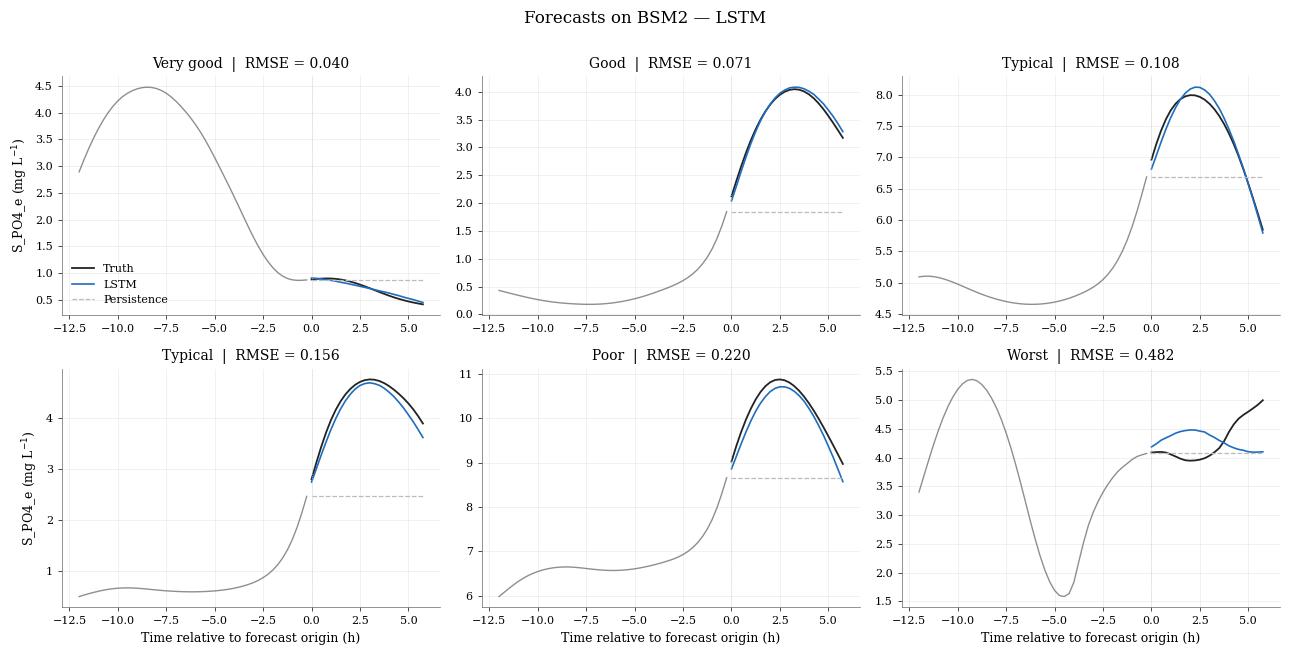

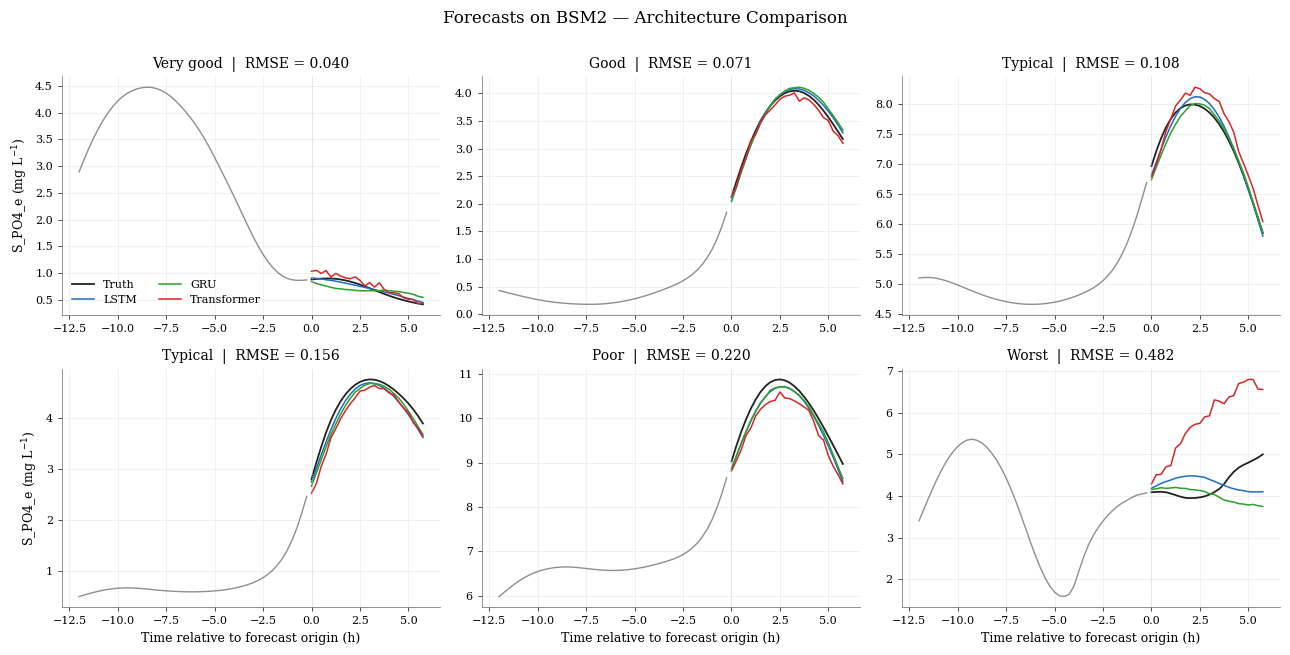


Saved → PLOTS/m1_forecasts_lstm.png
Saved → PLOTS/m1_forecasts_all.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# FORECAST DIAGNOSTIC PLOTS
# Produces two figures saved to PLOTS/:
#   m1_forecasts_lstm.png   (hero — main article)
#   m1_forecasts_all.png    (architecture comparison — appendix)
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

os.makedirs('PLOTS', exist_ok=True)

# ── Aesthetic helpers ────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)

# ── Load all available forecaster checkpoints ────────────────────────
DEVICE = next(iter(results.values()))['model'].parameters().__next__().device \
    if 'results' in dir() else torch.device('cpu')
forecasters_loaded = {}
for name in MODELS_TO_RUN:
    path = f'CHECKPOINTS/forecaster_{name}_{DATA_MODE}.pt'
    if not os.path.exists(path): continue
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    m = build_model(name).to(DEVICE)
    m.load_state_dict(ckpt['state_dict']); m.eval()
    forecasters_loaded[name] = m

# Restore scaler from the (any) checkpoint
ckpt_any = torch.load(f'CHECKPOINTS/forecaster_{list(forecasters_loaded)[0]}_{DATA_MODE}.pt',
                      map_location=DEVICE, weights_only=False)
sc_test = MinMaxScaler()
sc_test.data_min_   = np.array(ckpt_any['scaler_min'])
sc_test.data_range_ = np.array(ckpt_any['scaler_range'])
sc_test.scale_      = 1.0 / sc_test.data_range_
sc_test.min_        = -sc_test.data_min_ * sc_test.scale_
sc_test.n_features_in_ = len(sc_test.data_min_)

# ── Build non-overlapping test windows ───────────────────────────────
df_full = pd.read_csv(DATA_PATH)
df_full['timestamp'] = pd.to_datetime(df_full[TIMESTAMP_COL], format=TIMESTAMP_FMT)
df_full = df_full.sort_values('timestamp').set_index('timestamp')
df_m = df_full[ALL_VARS].copy()
for c in ALL_VARS:
    df_m[c] = df_m[c].interpolate('linear', limit_direction='both').ffill().bfill()
n_total = len(df_m)
train_end = int(n_total * TRAIN_RATIO)
val_end   = int(n_total * (TRAIN_RATIO + VAL_RATIO))
data_scaled_test = sc_test.transform(df_m.values)

L, H = INPUT_STEPS, HORIZON_STEPS
X_past, Y_fut, ts_origin = [], [], []
i = val_end
while i + L + H <= n_total:
    X_past.append(data_scaled_test[i : i + L])
    Y_fut.append(data_scaled_test[i + L : i + L + H, TARGET_IDX])
    ts_origin.append(df_m.index[i + L - 1])
    i += L
X_past = np.array(X_past); Y_fut = np.array(Y_fut)

# Predict with each loaded model
predictions = {}
for name, m in forecasters_loaded.items():
    with torch.no_grad():
        predictions[name] = m(torch.FloatTensor(X_past).to(DEVICE)).cpu().numpy()

# Inverse-transform helper for the target only
def inv_target(arr_scaled, target_col=0):
    pad = np.zeros((len(arr_scaled), N_VARS))
    pad[:, target_col] = arr_scaled
    return sc_test.inverse_transform(pad)[:, target_col]

# Per-window RMSE in original units, for the *primary* model (LSTM)
primary = 'LSTM' if 'LSTM' in predictions else list(predictions)[0]
rmse_primary = np.array([
    np.sqrt(mean_squared_error(
        inv_target(Y_fut[k, :, 0]),
        inv_target(predictions[primary][k, :, 0])
    )) for k in range(len(Y_fut))
])

# Persistence baseline
persist = np.broadcast_to(X_past[:, -1:, [TARGET_IDX[0]]], (len(X_past), H, 1)).copy()
rmse_persist = np.array([
    np.sqrt(mean_squared_error(
        inv_target(Y_fut[k, :, 0]),
        inv_target(persist[k, :, 0])
    )) for k in range(len(Y_fut))
])

# ── Pick 6 example windows spread across the RMSE distribution ──────
order = np.argsort(rmse_primary)
M = len(order)
pick_quantiles = [0.05, 0.20, 0.40, 0.60, 0.80, 0.95]
idxs = [order[int(q * (M - 1))] for q in pick_quantiles]
labels = ['Very good', 'Good', 'Typical', 'Typical', 'Poor', 'Worst']

# ── Time axis (hours relative to forecast origin) ────────────────────
t_past = np.arange(-L, 0) * RESOLUTION_MIN / 60
t_fut  = np.arange(0,  H) * RESOLUTION_MIN / 60

# ─────────────────────────────────────────────────────────────────────
# FIGURE 1 — HERO: LSTM only, with persistence baseline
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for k, (ax, idx, lab) in enumerate(zip(axes.flat, idxs, labels)):
    past   = inv_target(X_past[idx, :, 0])
    true_f = inv_target(Y_fut[idx, :, 0])
    pred_f = inv_target(predictions[primary][idx, :, 0])
    pers_f = inv_target(persist[idx, :, 0])
    ax.plot(t_past, past,   c='#444', lw=1.0, alpha=0.6)
    ax.plot(t_fut,  true_f, c='#222', lw=1.3,
            label='Truth' if k == 0 else None)
    ax.plot(t_fut,  pred_f, c='#1f6dbf', lw=1.2,
            label=primary if k == 0 else None)
    ax.plot(t_fut,  pers_f, c='#bbbbbb', lw=0.9, ls='--',
            label='Persistence' if k == 0 else None)
    ax.axvline(0, c='#cccccc', lw=0.5, ls=':')
    date = ts_origin[idx].strftime('%Y-%m-%d %H:%M')
    ax.set_title(f'{lab}  |  RMSE = {rmse_primary[idx]:.3f}', pad=6)
    if k % 3 == 0:           ax.set_ylabel(f'{TARGET_VARS[0]} (mg L$^{{-1}}$)')
    if k // 3 == 1:          ax.set_xlabel('Time relative to forecast origin (h)')
    if k == 0:               ax.legend(loc='lower left')
    style_axis(ax)
plt.suptitle(f'Forecasts on BSM2 — {primary}', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(f'PLOTS/m1_forecasts_{primary.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────
# FIGURE 2 — APPENDIX: all 3 architectures overlaid
# ─────────────────────────────────────────────────────────────────────
COLOURS = {'LSTM': '#1f6dbf', 'GRU': '#2ca02c', 'Transformer': '#d62728'}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for k, (ax, idx, lab) in enumerate(zip(axes.flat, idxs, labels)):
    past   = inv_target(X_past[idx, :, 0])
    true_f = inv_target(Y_fut[idx, :, 0])
    ax.plot(t_past, past,   c='#444', lw=1.0, alpha=0.6)
    ax.plot(t_fut,  true_f, c='#222', lw=1.3,
            label='Truth' if k == 0 else None)
    for name in ('LSTM', 'GRU', 'Transformer'):
        if name not in predictions: continue
        yp = inv_target(predictions[name][idx, :, 0])
        ax.plot(t_fut, yp, c=COLOURS[name], lw=1.1,
                label=name if k == 0 else None)
    ax.axvline(0, c='#cccccc', lw=0.5, ls=':')
    date = ts_origin[idx].strftime('%Y-%m-%d %H:%M')
    ax.set_title(f'{lab}  |  RMSE = {rmse_primary[idx]:.3f}', pad=6)
    if k % 3 == 0:  ax.set_ylabel(f'{TARGET_VARS[0]} (mg L$^{{-1}}$)')
    if k // 3 == 1: ax.set_xlabel('Time relative to forecast origin (h)')
    if k == 0:      ax.legend(loc='lower left', ncol=2)
    style_axis(ax)
plt.suptitle('Forecasts on BSM2 — Architecture Comparison', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('PLOTS/m1_forecasts_all.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved → PLOTS/m1_forecasts_{primary.lower()}.png')
print(f'Saved → PLOTS/m1_forecasts_all.png')

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

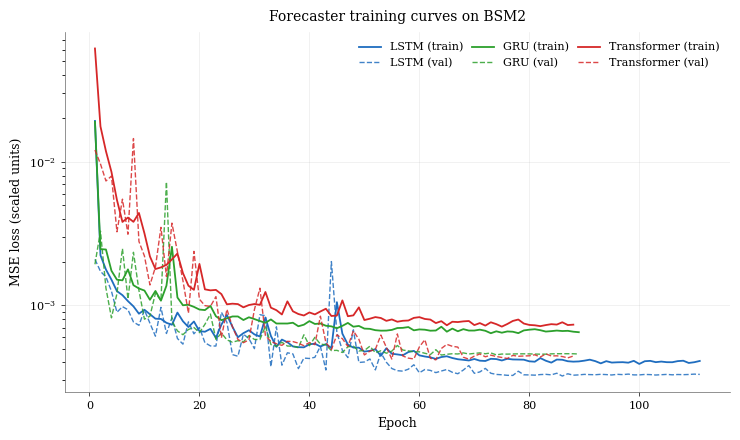

Saved → PLOTS/m1_training_curves.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# Produces one figure showing train + val loss vs epoch for all three
# architectures. Saved to PLOTS/m1_training_curves.png.
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, matplotlib.pyplot as plt
 
os.makedirs('PLOTS', exist_ok=True)
 
# ── Aesthetic helpers (same as forecast plots) ───────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})
 
def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)
 
# ── Colours (match forecast plots) ───────────────────────────────────
COLOURS = {'LSTM': '#1f6dbf', 'GRU': '#2ca02c', 'Transformer': '#d62728'}
 
# ─────────────────────────────────────────────────────────────────────
# FIGURE — train and val loss per architecture, single panel
# ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.5))
 
for name in ('LSTM', 'GRU', 'Transformer'):
    if name not in results: continue
    hist = results[name]['hist']
    epochs = np.arange(1, len(hist['train']) + 1)
    c = COLOURS[name]
    ax.plot(epochs, hist['train'], c=c, lw=1.3, ls='-',
            label=f'{name} (train)')
    ax.plot(epochs, hist['val'],   c=c, lw=1.0, ls='--',
            alpha=0.85, label=f'{name} (val)')
 
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss (scaled units)')
ax.set_title('Forecaster training curves on BSM2', pad=8)
ax.legend(loc='upper right', ncol=3, columnspacing=0.8)
style_axis(ax)
 
plt.tight_layout()
plt.savefig('PLOTS/m1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('Saved → PLOTS/m1_training_curves.png')

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

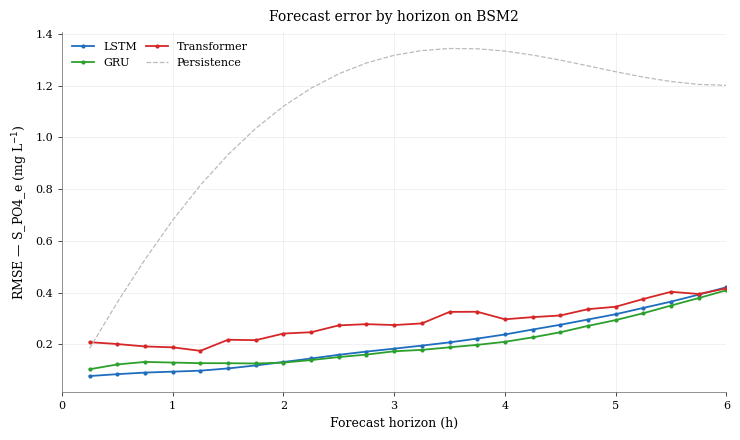

Saved → PLOTS/m1_rmse_by_horizon.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# RMSE BY HORIZON — paste after the forecast diagnostic cell in
# MODEL_1_FORECASTER. Requires `predictions`, `Y_fut`, `persist`, `inv_target`,
# `HORIZON_STEPS`, `RESOLUTION_MIN`, `TARGET_VARS`, and the loaded models
# to exist in the notebook namespace.
# Produces PLOTS/m1_rmse_by_horizon.png.
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, matplotlib.pyplot as plt

os.makedirs('PLOTS', exist_ok=True)

# ── Aesthetic helpers (same as other M1 plots) ───────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)

COLOURS = {'LSTM': '#1f6dbf', 'GRU': '#2ca02c', 'Transformer': '#d62728'}

# ── Compute RMSE per horizon step, in original units ─────────────────
horizons_h = np.arange(1, HORIZON_STEPS + 1) * RESOLUTION_MIN / 60

def rmse_per_horizon(yhat):
    out = []
    for h in range(HORIZON_STEPS):
        yt = inv_target(Y_fut[:, h, 0])
        yp = inv_target(yhat[:, h, 0])
        out.append(np.sqrt(np.mean((yt - yp) ** 2)))
    return np.array(out)

rmse_h = {name: rmse_per_horizon(predictions[name])
          for name in ('LSTM', 'GRU', 'Transformer') if name in predictions}
rmse_h_persist = rmse_per_horizon(persist)

# ─────────────────────────────────────────────────────────────────────
# FIGURE — single panel, RMSE vs horizon
# ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for name, rmse in rmse_h.items():
    ax.plot(horizons_h, rmse, c=COLOURS[name], lw=1.3, label=name,
            marker='o', markersize=3, markeredgewidth=0)

ax.plot(horizons_h, rmse_h_persist, c='#bbbbbb', lw=0.9, ls='--',
        label='Persistence')

ax.set_xlabel('Forecast horizon (h)')
ax.set_ylabel(f'RMSE — {TARGET_VARS[0]} (mg L$^{{-1}}$)')
ax.set_title('Forecast error by horizon on BSM2', pad=8)
ax.set_xlim(0, horizons_h[-1])
ax.legend(loc='upper left', ncol=2, columnspacing=0.8)
style_axis(ax)

plt.tight_layout()
plt.savefig('PLOTS/m1_rmse_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved → PLOTS/m1_rmse_by_horizon.png')